# TMA4135 - Exercise 7
Student: Magnus Ingnes Sagmo

In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np

## Problem 1 - Runge-Kutta
The classical 4th order Runge–Kutta method is given as:

$$
k_1 = f(t_n, y_n)
$$

$$
k_2 = f \left( t_n + \frac{h}{2}, y_n + \frac{h}{2} k_1 \right)
$$

$$
k_3 = f \left( t_n + \frac{h}{2}, y_n + \frac{h}{2} k_2 \right)
$$

$$
k_4 = f(t_n + h, y_n + h k_3)
$$

$$
y_{n+1} = y_n + \frac{h}{6} \left( k_1 + 2k_2 + 2k_3 + k_4 \right)
$$

a) Implement this method in Python

b) _Delievered on paper_


In [2]:
def runge_kutta_4(f, y0, t0, t_end, h):
    """
    The classical 4th-order Runge-Kutta method.
    
    Params
    ------
    f     : function `f(t, y)`
    y0    : initial value of y at t = t0
    t0    : initial time
    t_end : final time
    h     : step size
    
    Returns
    -------
    y : the estimated value of y at t_end
    """
    t_values = [t0]
    y_values = [y0]

    t = t0
    y = y0

    while t < t_end:
        if t + h > t_end:  # Ensure the last step reaches exactly t_end
            h = t_end - t
        k1 = f(t, y)
        k2 = f(t + (h/2), y + ((h/2) * k1))
        k3 = f(t + (h/2), y + ((h/2) * k2))
        k4 = f(t + h, y + (h * k3))

        # Update y and t using
        y = y + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        t = t + h

        t_values.append(t)
        y_values.append(y)
    
    print(f't: {t}')

    return y_values[-1]

t: 1.0
t: 1.0
t: 1.0
t: 1.0
t: 1.0
Step Size    Error
0.1          0.0000016253
0.05         0.0000001025
0.025        0.0000000064
0.0125       0.0000000004
0.00625      0.0000000000

Ratio of successive errors (should approximate 2^4 = 16 for p = 4):
Error ratio (h0/h1): 3.9865
Error ratio (h1/h2): 4.0004
Error ratio (h2/h3): 4.0018
Error ratio (h3/h4): 4.0013


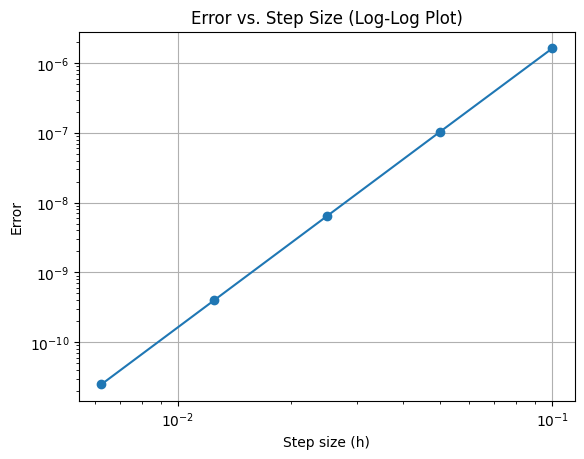

In [3]:
# Define y' = -2ty
def f(t, y):
    return -2 * t * y

# Main function to run the verification
def main():
    # Initial conditions
    y0 = 1
    t0 = 0
    t_end = 1  

    # Step sizes to try
    step_sizes = [0.1, 0.05, 0.025, 0.0125, 0.00625]

    estimated_sols = [runge_kutta_4(f=f, y0=y0, t0=t0,t_end=t_end, h=h) for h in step_sizes]
    exact_sol = np.exp(-t_end**2)
    errors = [abs(estimated_sol - exact_sol) for estimated_sol in estimated_sols]

    # Print the errors for each step size
    print("Step Size    Error")
    for h, error in zip(step_sizes, errors):
        print(f"{h:<12} {error:.10f}")

    # Compute the ratio of errors to verify the order of convergence
    print("\nRatio of successive errors (should approximate 2^4 = 16 for p = 4):")
    for i in range(len(errors) - 1):
        ratio = np.log(errors[i] / errors[i + 1])/np.log(step_sizes[i] / step_sizes[i+1])
        print(f"Error ratio (h{i}/h{i+1}): {ratio:.4f}")

    # Plotting the error vs. step size on a log-log scale
    plt.loglog(step_sizes, errors, '-o', label="Error")
    plt.xlabel("Step size (h)")
    plt.ylabel("Error")
    plt.title("Error vs. Step Size (Log-Log Plot)")
    plt.grid(True)
    plt.show()


# Run the main function
if __name__ == "__main__":
    main()

## Problem 2 - Error Search

a) There are three bugs in this code. Two that prevents it from running at all, and one which causes a completely nonsense output. Find and correct the errors.
1. `a` is not defined when instantiating `y[0]` - using `t0` instead.
2. The step size `h` is not defined - using `(tend-t0)/N`.
3. `t` is instantiated with only zeros, and never updated. It should rather be updated with the proper timesteps between `t0` and `tend`.

b) Which mathematical problem does this code intend to solve numerically?

This is solving an initial value problem for an ordinary differential equation.

c) Which specific algorithm has been applied to the problem? No specific name is required,but present the method in the form of a Butcher tableau, and decide the order of the method.

the algorithm used is a third order Runge-Kutta method.

d) Find the first two elements of the NumPy vector y, given that point a) is accomplished.



In [4]:
f = lambda t , y : 2/ t * y
t0 , tend = 1 , 2
y0 = 1
N = 10
h = (tend - t0) / N
y = np.zeros (N+1)
t = np.linspace(t0, tend, N)
y [0] = y0
t [0] = t0

for n in range (N) :
    k1 = f(t[n] , y[n])
    k2 = f(t[n]+0.5* h , y[n]+0.5 * h * k1)
    k3 = f(t[n]+0.75* h , y[n]+0.75 * h * k2)
    y[n+1] = y[n] + h * (2 * k1 +3* k2 +4 * k3) / 9

print ('t =', t)
print ('y =', y)

t = [1.         1.11111111 1.22222222 1.33333333 1.44444444 1.55555556
 1.66666667 1.77777778 1.88888889 2.        ]
y = [1.         1.20996678 1.43753484 1.68236912 1.9441696  2.22266513
 2.51760871 2.82877377 3.15595133 3.49894757 3.85758199]
